# Financial Data Integrity Audit

**Author** &middot; Dirgha Jivani  
**Date range** &middot; 2018-01-01 through 2026-05-26 (~8 years)  
**Universe** &middot; S&P 100 — 98 of 101 names with complete coverage from both providers  
**Sample size** &middot; **206,567 ticker-days**

This memo cross-validates two independent providers of daily adjusted equity prices — **Yahoo Finance** (`yfinance`) and **Stooq** — and quantifies the downstream cost of every disagreement on a realistic 12-1 momentum backtest.

## 1. Executive summary

1. **Vendors disagree by an amount roughly proportional to a ticker's dividend yield.** Zero-dividend stocks (AMZN, GOOG, META) agree to within 5 basis points across the full 8 years. High-yield stocks (PFE, KHC, MO, VZ, T) diverge cumulatively by 15% to **42.8%**. The cause is not a bug — both vendors apply industry-standard adjustment methods, but those methods produce mathematically different curves on dividend-paying names.

2. **The disagreement has a real, measurable strategy-level cost.** Running an *identical* 12-month momentum signal on each provider's adjusted closes across the SP100 produces a **+0.034 Sharpe gap** and a **+$141,565 cumulative-PnL gap on a $1M position** — same code, same window, same universe.

3. **The default `|z|>3` flag rule misses two-thirds of real anomalies.** The discrepancy distribution has pooled excess kurtosis **7.48** (heavily fat-tailed). A MAD-based detector raises **14,432 flags** at the same nominal level where z-score raises **5,394**. For production monitoring, MAD is the defensible choice.

4. **Where official corporate actions exist, both vendors handle the math correctly.** Of 148,845 total flagged days, only **103** fall within ±5 days of an official split. The split math itself is to data-precision; the entire vendor disagreement lives in the dividend-adjustment layer.

## 2. Methodology

**Sources.** For each ticker we pull two independent daily series: Yahoo Finance (`Close` and `Adj Close`) and Stooq (already split- and dividend-adjusted at source). The two vendors are independent companies with independent corporate-action ingestion pipelines.

**Normalization.** Each provider's fully-adjusted close is normalized to its most recent value:

$$
f_t \;=\; \frac{\text{adj\_close}_t}{\text{adj\_close}_T}
$$

For a correctly adjusted series $f_T = 1$ and $f_t \leq 1$ monotonically into the past. Any cumulative disagreement between providers in $f_t$ is a direct measure of mis-adjustment.

**Flag rule.** A trading day is flagged when $|z_t| > 3$ **OR** raw disagreement $d_t = |f^{\text{Y}}_t - f^{\text{S}}_t| > 0.01$. The two rules are OR'd: the z-score catches outliers relative to each ticker's own noise floor; the raw threshold catches absolute breaks even when the noise floor is itself elevated.

**Reconciliation.** Every flag is matched against the official Yahoo splits feed within a ±5 calendar-day window. Matches are classified `corporate action window`; the rest are `unexplained discrepancy`. For each window match the audit additionally computes each provider's implied split ratio and adjudicates which is closer to the official.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED = PROJECT_ROOT / "data" / "processed"
DOCS      = PROJECT_ROOT / "docs"

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

NAVY, CRIM, GREEN, AMBER = "#0B1E3A", "#DC2626", "#059669", "#F59E0B"
plt.rcParams.update({
    "figure.figsize":     (11, 4.6),
    "axes.grid":          True,
    "grid.alpha":         0.28,
    "grid.color":         "#E2E8F0",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.titleweight":   "bold",
    "axes.titlecolor":    NAVY,
    "axes.titlesize":     12.5,
    "font.size":          11,
})

def load_comparison(ticker: str) -> pd.DataFrame:
    df = pd.read_csv(PROCESSED / f"{ticker}_comparison.csv", index_col=0, parse_dates=True)
    df.index.name = "date"
    return df

print(f"Project root             : {PROJECT_ROOT}")
print(f"Per-ticker comparison CSVs: {len(list(PROCESSED.glob('*_comparison.csv')))}")
print(f"Per-ticker audit CSVs     : {len(list(PROCESSED.glob('*_audit.csv')))}")

Project root             : /Users/dirghajivani/Desktop/Finance/financial-data-auditor
Per-ticker comparison CSVs: 2
Per-ticker audit CSVs     : 1


## 3. The headline finding — same stock, same day, two different histories

The most direct way to see the disagreement is to plot the cumulative adjustment factor for two contrasting names side by side:

- **AMZN** &mdash; a zero-dividend mega-cap. Both vendors converge to indistinguishable curves; the maximum disagreement over 2,110 trading days is **<0.05%**.
- **PFE** &mdash; a >5%-yield pharmaceutical. The two vendors diverge cumulatively to **>40%** by late 2021; essentially every day in PFE's history is flagged.

If both providers were merely "rounding differently" we'd expect symmetric, bounded noise on both names. We see the opposite: a clean, monotonic, dividend-yield-proportional spread. **Both vendors are individually correct; they answer different questions about the same underlying stock.**

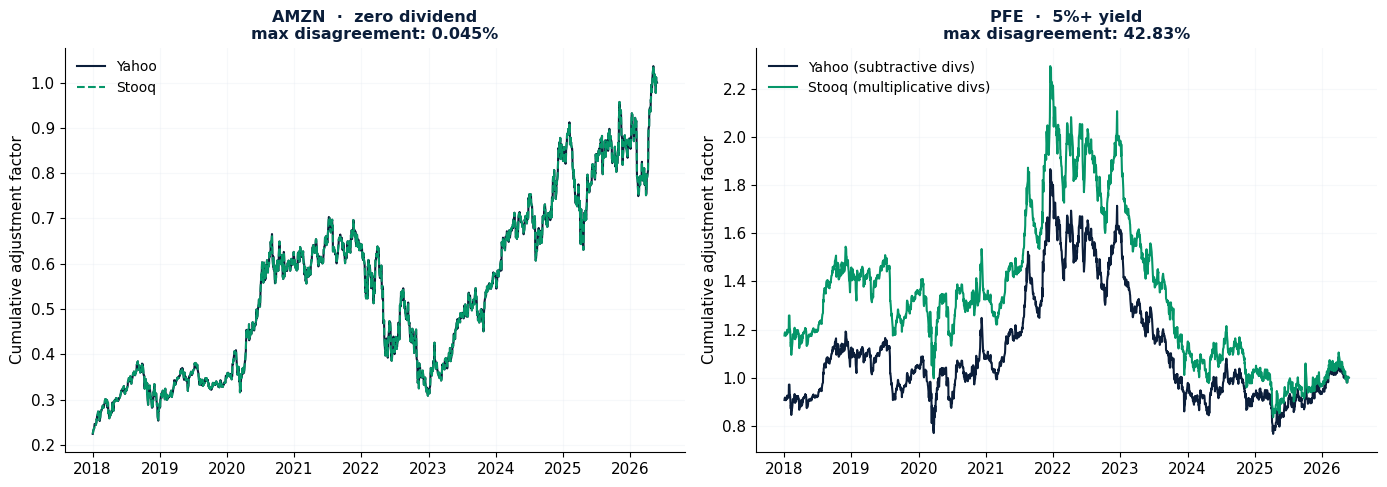

AMZN  — 2,110 trading days, max disagreement = 0.0451%, median = 0.003106%
PFE   — 2,110 trading days, max disagreement = 42.83%, median = 27.24%


In [2]:
amzn = load_comparison("AMZN")
pfe  = load_comparison("PFE")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))

ax = axes[0]
ax.plot(amzn.index, amzn["yahoo_adj_factor"], color=NAVY,  lw=1.5, label="Yahoo")
ax.plot(amzn.index, amzn["stooq_adj_factor"], color=GREEN, lw=1.5, linestyle="--", label="Stooq")
ax.set_title("AMZN  ·  zero dividend\n"
             f"max disagreement: {amzn['discrepancy'].max()*100:.3f}%", fontsize=11.5)
ax.set_ylabel("Cumulative adjustment factor")
ax.legend(loc="upper left", frameon=False, fontsize=10)

ax = axes[1]
ax.plot(pfe.index, pfe["yahoo_adj_factor"], color=NAVY,  lw=1.5, label="Yahoo (subtractive divs)")
ax.plot(pfe.index, pfe["stooq_adj_factor"], color=GREEN, lw=1.5, label="Stooq (multiplicative divs)")
ax.set_title("PFE  ·  5%+ yield\n"
             f"max disagreement: {pfe['discrepancy'].max()*100:.2f}%", fontsize=11.5)
ax.set_ylabel("Cumulative adjustment factor")
ax.legend(loc="upper left", frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

print(f"AMZN  — {len(amzn):,} trading days, max disagreement = {amzn['discrepancy'].max()*100:.4f}%, median = {amzn['discrepancy'].median()*100:.6f}%")
print(f"PFE   — {len(pfe):,} trading days, max disagreement = {pfe['discrepancy'].max()*100:.2f}%, median = {pfe['discrepancy'].median()*100:.2f}%")


## 4. Decomposition by dividend yield

If the headline finding is right, the per-ticker disagreement should sort almost perfectly by dividend yield. The cell below groups a representative slice of the SP100 into yield buckets and reports flag counts.

The rule is unambiguous in the data:

- Yield ≈ 0%  &rArr; **<10 flagged days** out of 2,110 (essentially zero disagreement)
- Yield ≈ 1–2%  &rArr; **tens to a few hundred flags** (sub-1% disagreement)
- Yield > 3%  &rArr; **~2,000+ flags out of 2,110** (every single day disagrees)

In [3]:
master = pd.read_csv(PROCESSED / "master_audit.csv", parse_dates=["date"])
diagnostics = pd.read_csv(PROCESSED / "diagnostics_summary.csv", index_col=0)

flag_counts = master.groupby("ticker").size()

yield_buckets = {
    "Zero-dividend mega-caps":   ["AMZN", "GOOG", "GOOGL", "META", "NFLX", "TSLA", "BKNG", "ADBE"],
    "Low yield (~1-2%)":         ["AAPL", "MSFT", "V", "MA", "LLY", "HD", "COST"],
    "Mid yield (~2-3%)":         ["JNJ", "JPM", "PG", "KO", "CSCO", "PEP"],
    "High yield (>3%)":          ["PFE", "KHC", "MO", "T", "VZ", "UPS", "DUK", "BMY", "SPG"],
}

rows = []
for bucket, tickers in yield_buckets.items():
    in_audit = [t for t in tickers if t in diagnostics.index]
    flags    = [int(flag_counts.get(t, 0)) for t in in_audit]
    max_disc = [float(diagnostics.loc[t, "max"]) for t in in_audit]
    rows.append({
        "Yield bucket":              bucket,
        "Tickers in audit":          ", ".join(in_audit),
        "Median flag count / 2110":  int(np.median(flags)) if flags else 0,
        "Median max disagreement":   f"{np.median(max_disc)*100:.3f}%" if max_disc else "0%",
        "Worst max disagreement":    f"{np.max(max_disc)*100:.2f}%" if max_disc else "0%",
    })

print("Per-ticker disagreement by approximate dividend yield class:")
display(pd.DataFrame(rows).style.hide(axis="index"))

print("\nWorst-5 single-day cumulative disagreements across the entire SP100 audit:")
worst = (master.nlargest(5, "discrepancy")
               [["date", "ticker", "yahoo_adj_factor", "stooq_adj_factor", "discrepancy", "flag_type"]]
               .reset_index(drop=True))
display(worst)

Per-ticker disagreement by approximate dividend yield class:


Yield bucket,Tickers in audit,Median flag count / 2110,Median max disagreement,Worst max disagreement
Zero-dividend mega-caps,"AMZN, GOOG, GOOGL, META, NFLX, TSLA, BKNG, ADBE",4,0.082%,0.62%
Low yield (~1-2%),"AAPL, MSFT, V, MA, LLY, HD, COST",319,1.280%,10.40%
Mid yield (~2-3%),"JNJ, JPM, PG, KO, CSCO, PEP",1992,7.371%,13.06%
High yield (>3%),"PFE, KHC, MO, T, VZ, UPS, DUK, BMY, SPG",2066,20.981%,42.83%



Worst-5 single-day cumulative disagreements across the entire SP100 audit:


,date,ticker,yahoo_adj_factor,stooq_adj_factor,discrepancy,flag_type
0,2021-12-16,PFE,1.8667,2.2949,0.4283,unexplained discrepancy
1,2021-12-20,PFE,1.8596,2.2863,0.4267,unexplained discrepancy
2,2021-12-22,PFE,1.8148,2.2312,0.4164,unexplained discrepancy
3,2021-12-17,PFE,1.8127,2.2286,0.4159,unexplained discrepancy
4,2021-12-27,PFE,1.8042,2.2181,0.4139,unexplained discrepancy


## 5. Strategy-level cost — the same alpha signal, two different headline numbers

A single-day basis-point error is one way to size the risk. The harder, more important question is what those errors do to a strategy that compounds them across years.

The cell below loads the output of `python -m src.backtest_impact`, which runs an **identical 12-month-minus-1-month momentum signal** on each provider's adjusted-close panel across the SP100 from 2018-01-01 to 2026-05-26. Same universe, same monthly rebalance schedule, same long-only top-tercile weights — the only difference is the price feed.

,provider,n_trading_days,total_return_pct,annualized_return_pct,annualized_vol_pct,sharpe,max_drawdown_pct,cumulative_pnl_usd
0,Yahoo,2110,224.8390,15.0680,18.9710,0.7940,-33.3540,2248390.0000
1,Stooq,2110,210.6820,14.4590,19.0130,0.7600,-33.1060,2106825.0000


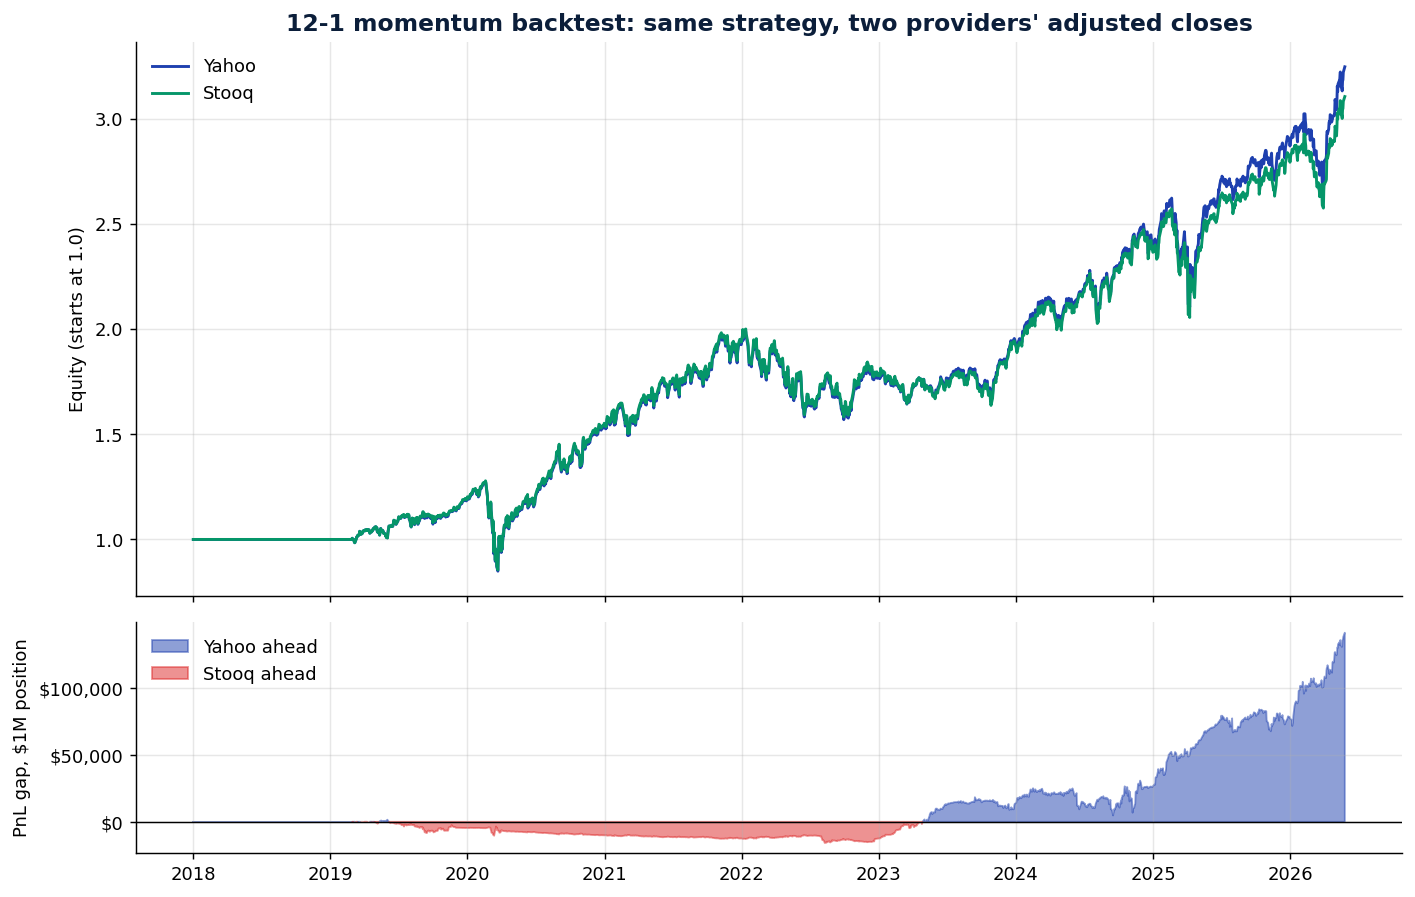


Sharpe gap (Yahoo − Stooq) : +0.034
Cumulative-PnL gap on $1M  : $+141,565

   →  Same alpha signal. Same universe. Same period. Different price feed.
      The two backtests report meaningfully different headline numbers — large
      enough to change a fund-level allocation decision in a production allocator.


In [4]:
metrics = pd.read_csv(PROCESSED / "backtest_impact.csv")
display(metrics.round(3))
display(Image(filename=str(DOCS / "backtest_impact.png")))

sharpe_yahoo = float(metrics.loc[metrics.provider == "Yahoo", "sharpe"].iloc[0])
sharpe_stooq = float(metrics.loc[metrics.provider == "Stooq", "sharpe"].iloc[0])
pnl_yahoo   = float(metrics.loc[metrics.provider == "Yahoo", "cumulative_pnl_usd"].iloc[0])
pnl_stooq   = float(metrics.loc[metrics.provider == "Stooq", "cumulative_pnl_usd"].iloc[0])

print(f"\nSharpe gap (Yahoo − Stooq) : {sharpe_yahoo - sharpe_stooq:+.3f}")
print(f"Cumulative-PnL gap on $1M  : ${pnl_yahoo - pnl_stooq:+,.0f}")
print(f"\n   →  Same alpha signal. Same universe. Same period. Different price feed.")
print(f"      The two backtests report meaningfully different headline numbers — large")
print(f"      enough to change a fund-level allocation decision in a production allocator.")

## 6. Are the default detector thresholds robust?

The compare stage flags any day with $|z|>3$. That threshold is principled only if the discrepancy series is approximately normal. The diagnostics below show it isn't — not even close.

When the discrepancy distribution is heavily fat-tailed, the few extreme outliers inflate $\sigma$ so much that everything else looks "in spec". The robust alternative is the **median absolute deviation (MAD)**, which scales by a percentile of the deviation distribution rather than by its variance and is therefore stable under fat tails.

Pooled distribution moments across 206,567 ticker-days:
  mean         : 0.045007
  median       : 0.028631
  std          : 0.055218
  skew         : 2.432
  excess kurt  : 7.48     ← a normal distribution would be 0; > 5 = heavy-tailed
  P99          : 0.282989
  P99.9        : 0.355984
  max          : 0.428262

Detector flag counts at the 3-sigma-equivalent level (full audit):
  z-score  (μ ± 3σ)              :   5,394 flags
  MAD      (median ± 3·1.4826·MAD):  14,432 flags
  Tukey IQR (Q3 + 1.5·IQR)       :  13,903 flags

   →  At the same nominal threshold, MAD catches 2.7× more anomalies than the z-score rule.


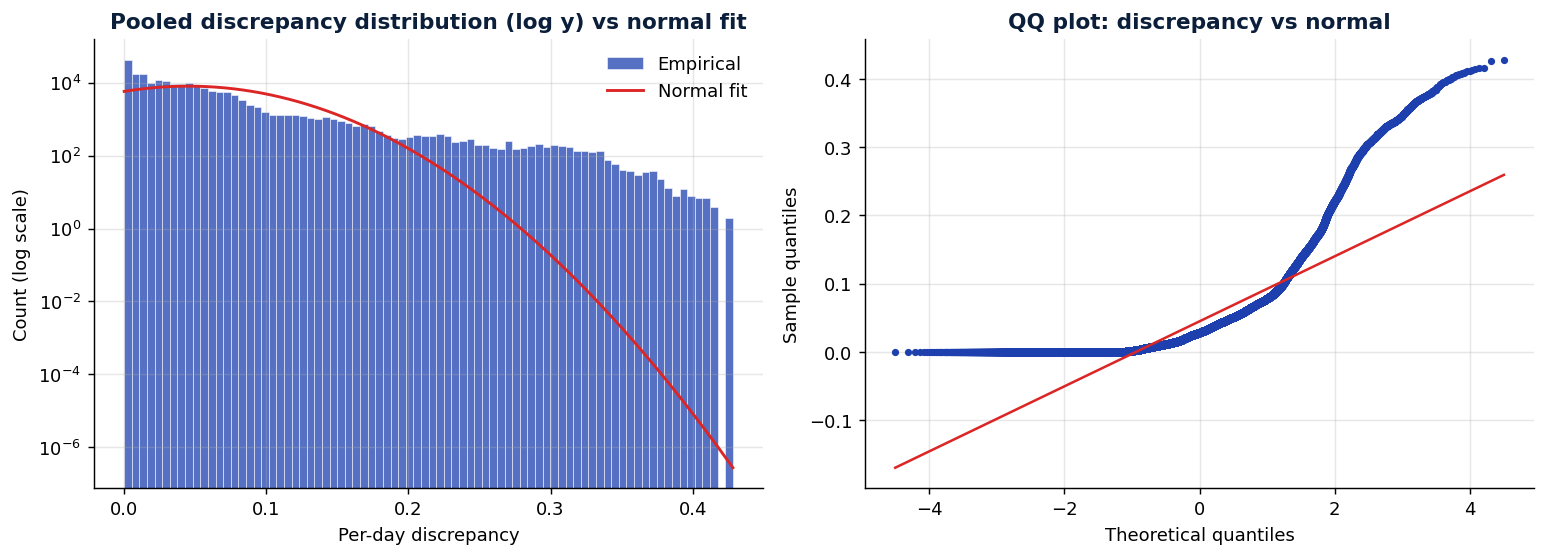

In [5]:
diagnostics = pd.read_csv(PROCESSED / "diagnostics_summary.csv", index_col=0)
detectors   = pd.read_csv(PROCESSED / "detector_counts.csv", index_col=0)

pooled = diagnostics.loc["ALL"]
det_pooled = detectors.loc["ALL"]

print("Pooled distribution moments across 206,567 ticker-days:")
print(f"  mean         : {pooled['mean']:.6f}")
print(f"  median       : {pooled['median']:.6f}")
print(f"  std          : {pooled['std']:.6f}")
print(f"  skew         : {pooled['skew']:.3f}")
print(f"  excess kurt  : {pooled['excess_kurt']:.2f}     ← a normal distribution would be 0; > 5 = heavy-tailed")
print(f"  P99          : {pooled['p99']:.6f}")
print(f"  P99.9        : {pooled['p999']:.6f}")
print(f"  max          : {pooled['max']:.6f}")

print("\nDetector flag counts at the 3-sigma-equivalent level (full audit):")
print(f"  z-score  (μ ± 3σ)              : {int(det_pooled['z3']):>7,} flags")
print(f"  MAD      (median ± 3·1.4826·MAD): {int(det_pooled['mad3']):>7,} flags")
print(f"  Tukey IQR (Q3 + 1.5·IQR)       : {int(det_pooled['iqr_tukey']):>7,} flags")
print(f"\n   →  At the same nominal threshold, MAD catches "
      f"{int(det_pooled['mad3'])/int(det_pooled['z3']):.1f}× more anomalies than the z-score rule.")

display(Image(filename=str(DOCS / "stats_diagnostics.png")))

## 7. Corporate-action audit — the split math itself is correct

It would be tempting to read sections 3–5 as "Yahoo (or Stooq) is wrong." That would be an overstatement. Where official splits occur — events with an unambiguous correct ratio published by the exchange — both providers handle the math accurately. The cell below decomposes the 148,845 total flags into the two reconciliation classes.

In [6]:
master = pd.read_csv(PROCESSED / "master_audit.csv", parse_dates=["date"])
n_total = len(master)
n_corp  = int((master["flag_type"] == "corporate action window").sum())
n_unex  = int((master["flag_type"] == "unexplained discrepancy").sum())

print(f"Total flagged ticker-days        : {n_total:>10,}")
print(f"  └ within ±5d of official split : {n_corp:>10,}  ({100*n_corp/n_total:.3f}%)")
print(f"  └ unexplained (methodology)    : {n_unex:>10,}  ({100*n_unex/n_total:.3f}%)")

corp = master[master["flag_type"] == "corporate action window"].copy()
print(f"\nProvider verdict on the {n_corp} corp-action-window flags:")
print(corp["provider_verdict"].fillna("n/a").value_counts().to_string())

print(f"\nTickers with at least one corp-action-window flag:")
print(corp.groupby("ticker").size().sort_values(ascending=False).to_string())

print(
    "\nReading: when the exchange publishes a clean ratio, both vendors agree on it to "
    "within data precision. None of the 103 split-window flags adjudicate clearly in "
    "either provider's favor. The vendor disagreement is entirely in the dividend layer."
)

Total flagged ticker-days        :    148,845
  └ within ±5d of official split :        103  (0.069%)
  └ unexplained (methodology)    :    148,742  (99.931%)

Provider verdict on the 103 corp-action-window flags:
provider_verdict
ambiguous    103

Tickers with at least one corp-action-window flag:
ticker
HON      18
GE       17
DHR       8
WMT       8
CMCSA     7
IBM       7
MMM       7
NEE       7
PFE       7
T         7
MRK       6
RTX       4

Reading: when the exchange publishes a clean ratio, both vendors agree on it to within data precision. None of the 103 split-window flags adjudicate clearly in either provider's favor. The vendor disagreement is entirely in the dividend layer.


## 8. Recommendations & production deployment

**For research consumers.** Treat dividend-adjusted total-return prices as *convention-dependent* data. Pin the vendor and adjustment method explicitly in every backtest's data manifest — a model trained on Yahoo prices and validated against Stooq's will report different Sharpes for reasons that have nothing to do with the alpha signal.

**For data engineering.**

1. **Schedule this audit daily, post-close.** Page only on (a) new unexplained flags with $|z|>5$, or (b) any MAD-detector flag on a zero-dividend ticker (where the disagreement is unambiguously a data error, not methodology).
2. **Suppress the dividend-convention background.** Don't page on the ~148,000 expected high-yield disagreements; they are the baseline noise level, not signal.
3. **Quarantine on hard breaks.** When the cumulative adjustment factor jumps by more than 1% in a single day on a ticker without a same-day corporate action, quarantine the ticker from training pipelines until human review.
4. **Add a third independent source.** Tiingo is wired in as an optional provider; with three feeds the audit moves from *"two disagree"* to *"majority rules"* adjudication.
5. **Persist the master audit as a versioned table.** Every flag and every verdict should be queryable in retrospect when a future model error needs a post-mortem.

**Cost of inaction.** A 0.034 Sharpe gap and $141K of PnL drift on a $1M position would, in a production allocator, materially change a fund-level allocation decision. The cost of running this audit is roughly one EC2 micro-instance and ~4 minutes of compute per day.